# 11. Rule-based Query Retrieval Baseline

## 1. 분석 목적

10차 분석에서는 자연어와 향수 데이터 사이의 연결 가능 범위를 Accord 92개, Note 2,523개,
Season 4개, Daypart 2개와 Evidence Level로 정리했다.

Evidence Level
(연결 관계가 얼마나 직접적인 데이터 근거를 가지고 있는지 나타내는 등급)은 다음과 같다.

- Level A — Direct: 표현과 데이터 Feature가 직접 대응
- Level B — Data Association: 두 Feature의 실제 동시 등장 관계
- Level C — Context Association: Season / Daypart community vote 관계
- Level D — External Mapping: 현재 데이터만으로 의미 연결 불가

이번 Notebook의 핵심 질문은 다음과 같다.

> 현재 데이터가 직접 이해할 수 있는 명확한 자연어 Query를 실제 향수 검색 결과까지 연결할 수 있는가?

이 Notebook은 자연어 추천의 첫 Rule-based Baseline
(사람이 정한 명확한 규칙만 사용하며, 앞으로 더 복잡한 방식과 비교할 가장 단순한 기준 모델)이다.


## 2. 분석 범위와 금지 사항

Strict Baseline(사용자가 직접 말한 Feature만 점수에 넣는 엄격한 기준)을 사용한다.

- LLM, Embedding, Machine Learning 학습을 사용하지 않는다.
- 감각 표현과 Scene 표현을 임의로 Accord / Note에 연결하지 않는다.
- Final Holdout, `reminds_me_of`, Golden Set을 사용하지 않는다.
- popularity는 추천 점수에 사용하지 않고, 결과 분포를 보는 진단에만 사용한다.
- Level B/C 관계는 Synthetic Query 문장 생성에만 쓸 수 있으며 Ranking Score에는 사용하지 않는다.
- 결과를 자연어 추천 정확도라고 표현하지 않는다.

`포근한`, `촉촉한`, `차분한`, `깨끗한`, `고급스러운`, `비 오는 숲`, `호텔`, `휴양지`, `이불`은
데이터에 직접 의미 label이 없으므로 `UNRESOLVED` 상태로 남긴다.


## 3. 환경 설정과 10차 산출물 로드

10차의 Level A와 Feature 사전을 규칙의 근거로 사용한다. Context Profile과 Level C는 합성 문장의
계절·시간대 조합을 고르는 데만 사용한다.


In [1]:
import array
import collections
import json
import pathlib
import re
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy import sparse

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

work_dir = pathlib.Path.cwd()
jsonl_path = work_dir / "perfumes.jsonl"
output_dir = work_dir / "analysis_outputs"
output_dir.mkdir(exist_ok=True)

required_paths = {
    "perfumes": jsonl_path,
    "query_bridge": output_dir / "10_query_feature_bridge.csv",
    "accord_dictionary": output_dir / "10_accord_dictionary.csv",
    "note_dictionary": output_dir / "10_note_dictionary.csv",
    "accord_context": output_dir / "10_accord_context_profile.csv",
}
for label, path in required_paths.items():
    if not path.is_file():
        raise FileNotFoundError(f"{label}: {path}")

query_bridge_10_df = pd.read_csv(required_paths["query_bridge"])
accord_dictionary_df = pd.read_csv(required_paths["accord_dictionary"])
note_dictionary_df = pd.read_csv(required_paths["note_dictionary"])
accord_context_df = pd.read_csv(required_paths["accord_context"])

input_summary = pd.DataFrame([
    ("10_query_feature_bridge", len(query_bridge_10_df)),
    ("10_accord_dictionary", len(accord_dictionary_df)),
    ("10_note_dictionary", len(note_dictionary_df)),
    ("10_accord_context_profile", len(accord_context_df)),
], columns=["input", "rows"])
display(input_summary)


,input,rows
0,10_query_feature_bridge,10544
1,10_accord_dictionary,92
2,10_note_dictionary,2523
3,10_accord_context_profile,92


## 4. Level A Rule Lexicon 생성

Rule Lexicon
(사용자 문장에서 어떤 표면 표현을 어떤 Feature로 연결할지 저장한 사전)은 10차 Level A Direct Mapping을
기준으로 만든다. 영문 Season/Daypart와 허용된 단순 번역·일반적 음차만 추가한다.

`포근한 → powdery`처럼 의미를 추론하는 규칙은 만들지 않는다. 같은 글자가 Accord와 Note 양쪽에 존재할
수 있으므로 두 규칙을 모두 보존하고 Parser 단계에서 `향` / `노트` 표지를 이용한다.


In [2]:
def normalize_text(text):
    text = unicodedata.normalize("NFKC", str(text)).casefold()
    return re.sub(r"\s+", " ", text).strip()


lexicon_rows = []

def add_lexicon(surface_form, feature_type, feature_name, mapping_type):
    lexicon_rows.append({
        "surface_form": str(surface_form),
        "normalized_form": normalize_text(surface_form),
        "feature_type": str(feature_type),
        "feature_name": str(feature_name),
        "mapping_type": str(mapping_type),
        "evidence_level": "A",
    })


level_a_bridge = query_bridge_10_df[
    query_bridge_10_df["evidence_level"].eq("A")
]
for row in level_a_bridge.itertuples(index=False):
    add_lexicon(
        row.source_expression,
        row.target_type,
        row.target_feature,
        "LEVEL_A_DIRECT",
    )

# 명시적인 영어 context 별칭
for surface, feature in [
    ("winter", "winter"), ("spring", "spring"),
    ("summer", "summer"), ("autumn", "autumn"), ("fall", "autumn"),
]:
    add_lexicon(surface, "SEASON", feature, "ENGLISH_CONTEXT_ALIAS")
for surface, feature in [("day", "day"), ("night", "night")]:
    add_lexicon(surface, "DAYPART", feature, "ENGLISH_CONTEXT_ALIAS")

# 단순 번역 또는 일반적 음차만 허용한 제한적 한국어 Accord 별칭
safe_korean_accord_aliases = {
    "시트러스": "citrus",
    "우디": "woody",
    "바닐라": "vanilla",
    "플로럴": "floral",
    "프루티": "fruity",
    "파우더리": "powdery",
    "아로마틱": "aromatic",
    "앰버": "amber",
    "스위트": "sweet",
    "프레시": "fresh",
}
known_accords = set(accord_dictionary_df["accord"])
for surface, feature in safe_korean_accord_aliases.items():
    if feature in known_accords:
        add_lexicon(surface, "ACCORD", feature, "KOREAN_TRANSLITERATION")

rule_lexicon_df = (
    pd.DataFrame(lexicon_rows)
    .drop_duplicates(["normalized_form", "feature_type", "feature_name"])
    .sort_values(
        ["normalized_form", "feature_type", "feature_name", "mapping_type"]
    )
    .reset_index(drop=True)
)
rule_lexicon_df.to_csv(
    output_dir / "11_rule_lexicon.csv", index=False, encoding="utf-8-sig"
)

print(f"Rule 수: {len(rule_lexicon_df):,}")
display(rule_lexicon_df.groupby(
    ["feature_type", "mapping_type"], dropna=False
).size().to_frame("rule_count"))
display(rule_lexicon_df.head(30))


Rule 수: 2,638


rule_count
feature_type mapping_type                      
ACCORD       KOREAN_TRANSLITERATION          10
             LEVEL_A_DIRECT                  92
DAYPART      ENGLISH_CONTEXT_ALIAS            2
             LEVEL_A_DIRECT                   2
NOTE         LEVEL_A_DIRECT                2523
SEASON       ENGLISH_CONTEXT_ALIAS            5
             LEVEL_A_DIRECT                   4

,surface_form,normalized_form,feature_type,feature_name,mapping_type,evidence_level
0,Abelia,abelia,NOTE,Abelia,LEVEL_A_DIRECT,A
1,Absinthe,absinthe,NOTE,Absinthe,LEVEL_A_DIRECT,A
2,Acai Berry,acai berry,NOTE,Acai Berry,LEVEL_A_DIRECT,A
3,Accord Eudora®,accord eudora®,NOTE,Accord Eudora®,LEVEL_A_DIRECT,A
4,Acerola,acerola,NOTE,Acerola,LEVEL_A_DIRECT,A
5,Acerola Blossom,acerola blossom,NOTE,Acerola Blossom,LEVEL_A_DIRECT,A
6,Acetylfuran,acetylfuran,NOTE,Acetylfuran,LEVEL_A_DIRECT,A
7,Achillea Olympus,achillea olympus,NOTE,Achillea Olympus,LEVEL_A_DIRECT,A
8,Acorn,acorn,NOTE,Acorn,LEVEL_A_DIRECT,A
9,Acronychia pedunculata,acronychia pedunculata,NOTE,Acronychia pedunculata,LEVEL_A_DIRECT,A


## 5. Query Parser와 Target Profile

Query Parser
(문장에서 알고 있는 표현을 찾아 구조화된 Feature로 바꾸는 기능)는 긴 표현부터 찾고 겹치는 짧은 표현을
다시 세지 않는다. 영문은 단어 경계를 사용해 `rose`가 더 긴 단어의 일부로 잘못 잡히는 것을 막는다.

Accord/Note가 같은 표면형을 공유하면 다음의 명시적 표지만 사용한다.

- 뒤에 `노트` 또는 `note`가 있으면 Note
- 뒤에 `향` 또는 `accord`가 있으면 Accord
- 표지가 없으면 대문자로 시작한 canonical 표면은 Note, 그 외는 Accord

마지막 규칙은 의미 추론이 아니라 표기 충돌을 재현 가능하게 해소하기 위한 형식 규칙이다.

Target Profile
(사용자가 원하는 조건을 구조화한 데이터 표현)은 사용자가 직접 언급한 Feature만 가중치 1.0으로 담는다.


In [3]:
rules_by_surface = collections.defaultdict(list)
for row in rule_lexicon_df.to_dict("records"):
    rules_by_surface[row["normalized_form"]].append(row)
sorted_surfaces = sorted(rules_by_surface, key=lambda value: (-len(value), value))

# 구체 장면을 먼저 검사한 뒤 일반 형용사를 검사한다.
unresolved_patterns = [
    (r"비\s*오는\s*숲", "비 오는 숲"),
    (r"고급\s*호텔\s*로비", "고급 호텔 로비"),
    (r"따뜻한\s*이불", "따뜻한 이불"),
    (r"호텔\s*로비", "호텔 로비"),
    (r"포근(?:한|하고|하게)?", "포근한"),
    (r"촉촉(?:한|하고|하게)?", "촉촉한"),
    (r"차분(?:한|하고|하게)?", "차분한"),
    (r"깨끗(?:한|하고|하게)?", "깨끗한"),
    (r"고급스러(?:운|워|움)?", "고급스러운"),
    (r"휴양지", "휴양지"),
    (r"호텔", "호텔"),
    (r"이불", "이불"),
]


def spans_overlap(span, occupied):
    start, end = span
    return any(start < used_end and used_start < end for used_start, used_end in occupied)


def surface_matches(normalized_query, surface):
    escaped = re.escape(surface)
    if re.search(r"[a-z0-9]", surface):
        pattern = rf"(?<![a-z0-9]){escaped}(?![a-z0-9])"
    else:
        pattern = escaped
    return list(re.finditer(pattern, normalized_query))


def choose_rule(candidates, original_fragment, after_text):
    by_type = collections.defaultdict(list)
    for candidate in candidates:
        by_type[candidate["feature_type"]].append(candidate)

    if "NOTE" in by_type and re.search(r"^\s*(노트|note)", after_text):
        return by_type["NOTE"][0]
    if "ACCORD" in by_type and re.search(r"^\s*(향|accord)", after_text):
        return by_type["ACCORD"][0]
    if "SEASON" in by_type:
        return by_type["SEASON"][0]
    if "DAYPART" in by_type:
        return by_type["DAYPART"][0]
    if len(by_type) == 1:
        return candidates[0]
    if "NOTE" in by_type and any(character.isupper() for character in original_fragment):
        return by_type["NOTE"][0]
    if "ACCORD" in by_type:
        return by_type["ACCORD"][0]
    return candidates[0]


def parse_query(query):
    normalized_query = normalize_text(query)
    occupied = []
    resolved_matches = []

    for surface in sorted_surfaces:
        for match in surface_matches(normalized_query, surface):
            span = match.span()
            if spans_overlap(span, occupied):
                continue
            original_fragment = str(query)[span[0]:span[1]]
            after_text = normalized_query[span[1]:span[1] + 12]
            chosen = choose_rule(
                rules_by_surface[surface], original_fragment, after_text
            )
            resolved_matches.append((span[0], chosen))
            occupied.append(span)

    unresolved_matches = []
    for pattern, label in unresolved_patterns:
        for match in re.finditer(pattern, normalized_query):
            if spans_overlap(match.span(), occupied):
                continue
            unresolved_matches.append((match.start(), label))
            occupied.append(match.span())

    result = {
        "accords": [],
        "notes": [],
        "seasons": [],
        "dayparts": [],
        "unresolved": [],
    }
    target_key = {
        "ACCORD": "accords",
        "NOTE": "notes",
        "SEASON": "seasons",
        "DAYPART": "dayparts",
    }
    for _, chosen in sorted(resolved_matches, key=lambda item: item[0]):
        key = target_key[chosen["feature_type"]]
        feature = chosen["feature_name"]
        if feature not in result[key]:
            result[key].append(feature)
    for _, label in sorted(unresolved_matches, key=lambda item: item[0]):
        if label not in result["unresolved"]:
            result["unresolved"].append(label)
    return result


def make_target_profile(parsed):
    return {
        "accords": {feature: 1.0 for feature in parsed["accords"]},
        "notes": {feature: 1.0 for feature in parsed["notes"]},
        "season": {feature: 1.0 for feature in parsed["seasons"]},
        "daypart": {feature: 1.0 for feature in parsed["dayparts"]},
    }


def resolution_summary(parsed):
    resolved_count = sum(len(parsed[key]) for key in (
        "accords", "notes", "seasons", "dayparts"
    ))
    unresolved_count = len(parsed["unresolved"])
    denominator = resolved_count + unresolved_count
    resolution_rate = resolved_count / denominator if denominator else 0.0
    if resolved_count == 0:
        status = "UNRESOLVED"
    elif unresolved_count:
        status = "PARTIALLY_RESOLVED"
    else:
        status = "RESOLVED"
    return {
        "status": status,
        "resolved_count": resolved_count,
        "unresolved_count": unresolved_count,
        "resolution_rate": resolution_rate,
    }


### Parser 기본 예시

Parser는 데이터에 없는 의미를 추론하지 않는다. 아래 세 예시로 직접, context, unresolved 처리를 확인한다.


In [4]:
parser_examples = [
    "여름 낮에 어울리는 citrus 향",
    "Vanilla 노트가 느껴지는 겨울 향",
    "비 오는 숲처럼 촉촉한 향",
]
for query in parser_examples:
    parsed = parse_query(query)
    print(query)
    print(json.dumps(parsed, ensure_ascii=False, indent=2))
    print(json.dumps(make_target_profile(parsed), ensure_ascii=False, indent=2))
    print()


여름 낮에 어울리는 citrus 향
{
  "accords": [
    "citrus"
  ],
  "notes": [],
  "seasons": [
    "summer"
  ],
  "dayparts": [
    "day"
  ],
  "unresolved": []
}
{
  "accords": {
    "citrus": 1.0
  },
  "notes": {},
  "season": {
    "summer": 1.0
  },
  "daypart": {
    "day": 1.0
  }
}



Vanilla 노트가 느껴지는 겨울 향
{
  "accords": [],
  "notes": [
    "Vanilla"
  ],
  "seasons": [
    "winter"
  ],
  "dayparts": [],
  "unresolved": []
}
{
  "accords": {},
  "notes": {
    "Vanilla": 1.0
  },
  "season": {
    "winter": 1.0
  },
  "daypart": {}
}

비 오는 숲처럼 촉촉한 향
{
  "accords": [],
  "notes": [],
  "seasons": [],
  "dayparts": [],
  "unresolved": [
    "비 오는 숲",
    "촉촉한"
  ]
}
{
  "accords": {},
  "notes": {},
  "season": {},
  "daypart": {}
}



## 6. 향수 Retrieval Feature Matrix 생성

`perfumes.jsonl`을 한 번 스트리밍해 향수 ID·이름·브랜드와 다음 행렬을 만든다.

- Accord strength: `strength / 100` 점수 계산용 sparse matrix(값이 있는 위치만 저장하는 행렬)
- Union Note: 존재 여부 sparse matrix
- Season / Daypart: total vote 20 이상이면 share, 아니면 `UNKNOWN`을 뜻하는 `NaN`
- popularity magnitude: 추천과 무관한 진단 열

`similar` 관계나 평가용 관계 데이터는 읽지 않는다.


In [5]:
accord_to_col = {
    name: index for index, name in enumerate(accord_dictionary_df["accord"])
}
note_to_col = {
    name: index for index, name in enumerate(note_dictionary_df["note"])
}
accord_names = accord_dictionary_df["accord"].tolist()
note_names = note_dictionary_df["note"].tolist()

perfume_ids = array.array("i")
perfume_names = []
perfume_brands = []
popularity_values = array.array("f")

accord_rows = array.array("i")
accord_cols = array.array("i")
accord_values = array.array("f")
note_rows = array.array("i")
note_cols = array.array("i")

season_share_columns = {name: array.array("f") for name in ("winter", "spring", "summer", "autumn")}
daypart_share_columns = {name: array.array("f") for name in ("day", "night")}

with jsonl_path.open("r", encoding="utf-8") as file:
    for row_index, line in enumerate(file):
        if not line.strip():
            continue
        record = json.loads(line)
        perfume_ids.append(int(record["id"]))
        perfume_names.append(record.get("name") or "")
        perfume_brands.append(record.get("brand") or "")

        # 같은 향수 안의 Accord 중복은 최대 strength로 통합한다.
        strength_by_col = {}
        for item in record.get("accords") or []:
            name = item.get("name")
            strength = item.get("strength")
            if name not in accord_to_col or strength is None:
                continue
            column = accord_to_col[name]
            strength = float(strength)
            previous = strength_by_col.get(column)
            if previous is None or strength > previous:
                strength_by_col[column] = strength
        for column, strength in strength_by_col.items():
            accord_rows.append(row_index)
            accord_cols.append(column)
            accord_values.append(strength)

        notes = record.get("notes") or {}
        tiered = notes.get("tiered") or {}
        union_notes = set()
        for tier in ("top", "middle", "base"):
            union_notes.update(
                item.get("name")
                for item in tiered.get(tier) or []
                if item.get("name")
            )
        union_notes.update(
            item.get("name")
            for item in notes.get("flat") or []
            if item.get("name")
        )
        for name in union_notes:
            if name in note_to_col:
                note_rows.append(row_index)
                note_cols.append(note_to_col[name])

        seasons = record.get("seasons") or {}
        season_votes = np.asarray([
            float(seasons.get(name, 0) or 0)
            for name in ("winter", "spring", "summer", "autumn")
        ], dtype=np.float64)
        season_total = season_votes.sum()
        season_shares = season_votes / season_total if season_total >= 20 else np.full(4, np.nan)
        for name, value in zip(("winter", "spring", "summer", "autumn"), season_shares):
            season_share_columns[name].append(float(value))

        daypart = record.get("daypart") or {}
        daypart_votes = np.asarray([
            float(daypart.get(name, 0) or 0) for name in ("day", "night")
        ], dtype=np.float64)
        daypart_total = daypart_votes.sum()
        daypart_shares = daypart_votes / daypart_total if daypart_total >= 20 else np.full(2, np.nan)
        for name, value in zip(("day", "night"), daypart_shares):
            daypart_share_columns[name].append(float(value))

        magnitude = (record.get("popularity") or {}).get("magnitude")
        popularity_values.append(float(magnitude) if magnitude is not None else np.nan)

n_perfumes = len(perfume_ids)
accord_strength_matrix = sparse.csr_matrix(
    (
        np.asarray(accord_values, dtype=np.float32),
        (np.asarray(accord_rows, dtype=np.int32), np.asarray(accord_cols, dtype=np.int32)),
    ),
    shape=(n_perfumes, len(accord_names)),
    dtype=np.float32,
)
note_presence_matrix = sparse.csr_matrix(
    (
        np.ones(len(note_rows), dtype=np.float32),
        (np.asarray(note_rows, dtype=np.int32), np.asarray(note_cols, dtype=np.int32)),
    ),
    shape=(n_perfumes, len(note_names)),
    dtype=np.float32,
)
note_presence_matrix.sum_duplicates()
note_presence_matrix.data[:] = 1.0

season_matrix = np.column_stack([
    np.asarray(season_share_columns[name], dtype=np.float32)
    for name in ("winter", "spring", "summer", "autumn")
])
daypart_matrix = np.column_stack([
    np.asarray(daypart_share_columns[name], dtype=np.float32)
    for name in ("day", "night")
])
perfume_ids = np.asarray(perfume_ids, dtype=np.int32)
popularity_values = np.asarray(popularity_values, dtype=np.float64)

season_to_col = {name: index for index, name in enumerate(("winter", "spring", "summer", "autumn"))}
daypart_to_col = {name: index for index, name in enumerate(("day", "night"))}

matrix_summary = pd.DataFrame([
    ("Perfumes", n_perfumes, np.nan),
    ("Accord strength", accord_strength_matrix.shape, accord_strength_matrix.nnz),
    ("Union Note", note_presence_matrix.shape, note_presence_matrix.nnz),
    ("Reliable Season", int(np.isfinite(season_matrix[:, 0]).sum()), np.nan),
    ("Reliable Daypart", int(np.isfinite(daypart_matrix[:, 0]).sum()), np.nan),
], columns=["item", "shape_or_count", "nonzero"])
display(matrix_summary)

assert accord_strength_matrix.shape == (n_perfumes, len(accord_dictionary_df))
assert note_presence_matrix.shape == (n_perfumes, len(note_dictionary_df))


,item,shape_or_count,nonzero
0,Perfumes,131930,NaN
1,Accord strength,"(131930, 92)","1,000,570.000000"
2,Union Note,"(131930, 2523)","1,091,811.000000"
3,Reliable Season,57533,NaN
4,Reliable Daypart,44421,NaN


## 7. Match Score와 Missing Community 처리

사용자가 실제로 언급한 category만 계산한다.

- Accord Match Score(요청 Accord가 향수에서 얼마나 강한지): 요청 strength/100의 평균
- Note Match Score(요청 Note가 실제 목록에 있는 비율): 요청 Note 존재 비율
- Season Match Score(요청 계절과 community 평가가 맞는 정도): reliable 향수의 요청 season share
- Daypart Match Score(요청 시간대와 community 평가가 맞는 정도): reliable 향수의 요청 daypart share

Note IDF는 사용하지 않는다. 사용자가 Note를 직접 말한 경우에는 희귀성보다 존재 여부가 더 직접적인
의미이기 때문이다.

데이터에는 주요 Accord 최대 약 8개만 기록되어 있으므로 Accord Match 0은 실제 향이 완전히 없다는 뜻이
아니라 관측된 주요 Accord 목록에 없다는 뜻이다.

Season/Daypart total vote가 20 미만이면 0이 아니라 `UNKNOWN(NaN)`으로 둔다.


### Final Baseline Score

Evidence Coverage
(사용자가 요구한 category 중 해당 향수에서 실제로 확인할 수 있는 정보의 비율)를 별도로 계산한다.

\[
Base\ Match = mean(사용 가능한 category\ score)
\]

\[
Final\ Baseline\ Score = Base\ Match \times Evidence\ Coverage
\]

모든 요청 category가 `UNKNOWN`이면 Base Match는 `NaN`, Coverage와 Final은 0이다. 이 규칙은 정답이
아니라 설명 가능한 첫 기준이며, 향후 Golden Set
(추천 결과가 맞는지 평가하기 위해 사람이 정답을 붙인 데이터)을 만든 뒤 조합 방식도 검증해야 한다.


In [6]:
def mean_sparse_columns(matrix, columns, scale=1.0):
    values = np.asarray(matrix[:, columns].mean(axis=1)).ravel()
    return values / scale


def score_query(parsed):
    category_arrays = {}
    if parsed["accords"]:
        columns = [accord_to_col[name] for name in parsed["accords"]]
        category_arrays["accord_match"] = mean_sparse_columns(
            accord_strength_matrix, columns, scale=100.0
        )
    if parsed["notes"]:
        columns = [note_to_col[name] for name in parsed["notes"]]
        category_arrays["note_match"] = mean_sparse_columns(
            note_presence_matrix, columns
        )
    if parsed["seasons"]:
        columns = [season_to_col[name] for name in parsed["seasons"]]
        submatrix = season_matrix[:, columns]
        reliable = np.isfinite(submatrix).all(axis=1)
        values = np.full(n_perfumes, np.nan, dtype=np.float64)
        values[reliable] = submatrix[reliable].mean(axis=1)
        category_arrays["season_match"] = values
    if parsed["dayparts"]:
        columns = [daypart_to_col[name] for name in parsed["dayparts"]]
        submatrix = daypart_matrix[:, columns]
        reliable = np.isfinite(submatrix).all(axis=1)
        values = np.full(n_perfumes, np.nan, dtype=np.float64)
        values[reliable] = submatrix[reliable].mean(axis=1)
        category_arrays["daypart_match"] = values

    if not category_arrays:
        raise ValueError("Resolved feature가 없는 Query는 retrieval하지 않습니다.")

    stacked = np.vstack(list(category_arrays.values()))
    available_count = np.isfinite(stacked).sum(axis=0)
    score_sum = np.nansum(stacked, axis=0)
    base_match = np.divide(
        score_sum,
        available_count,
        out=np.full(n_perfumes, np.nan, dtype=np.float64),
        where=available_count > 0,
    )
    evidence_coverage = available_count / len(category_arrays)
    final_score = np.where(
        available_count > 0,
        base_match * evidence_coverage,
        0.0,
    )

    output = {
        "accord_match": np.full(n_perfumes, np.nan),
        "note_match": np.full(n_perfumes, np.nan),
        "season_match": np.full(n_perfumes, np.nan),
        "daypart_match": np.full(n_perfumes, np.nan),
        "base_match_score": base_match,
        "evidence_coverage": evidence_coverage,
        "final_score": final_score,
    }
    output.update(category_arrays)
    return output


## 8. Synthetic Query Set 생성

Synthetic Query
(정답 Feature를 알고 있는 상태에서 Parser 동작을 시험하려고 자동 생성한 문장)는 실제 사용자 평가
데이터가 아니다.

- Accord Only: 빈도 상위 30개
- Note Only: 빈도와 안정성이 충분한 상위 30개
- Context Only: Season 4개, Daypart 2개
- Accord + Season: 상위 Accord 20개와 10차 Level C Season Lift가 가장 높은 계절
- Accord + Daypart: 상위 Accord 20개와 10차 Level C Daypart Lift가 가장 높은 시간대
- Accord + Season + Daypart: 같은 방식의 대표 조합 20개

Level C는 문장 생성에만 쓰며 Score에는 직접 언급된 Feature만 들어간다.


In [7]:
season_ko = {"winter": "겨울", "spring": "봄", "summer": "여름", "autumn": "가을"}
daypart_ko = {"day": "낮", "night": "밤"}

level_c_season = query_bridge_10_df[
    query_bridge_10_df["evidence_level"].eq("C")
    & query_bridge_10_df["target_type"].eq("SEASON")
].sort_values(
    ["source_expression", "association_score", "target_feature"],
    ascending=[True, False, True],
)
best_season_by_accord = (
    level_c_season.drop_duplicates("source_expression")
    .set_index("source_expression")["target_feature"]
    .to_dict()
)
level_c_daypart = query_bridge_10_df[
    query_bridge_10_df["evidence_level"].eq("C")
    & query_bridge_10_df["target_type"].eq("DAYPART")
].sort_values(
    ["source_expression", "association_score", "target_feature"],
    ascending=[True, False, True],
)
best_daypart_by_accord = (
    level_c_daypart.drop_duplicates("source_expression")
    .set_index("source_expression")["target_feature"]
    .to_dict()
)

synthetic_rows = []

def add_synthetic(query_type, query, accords=(), notes=(), seasons=(), dayparts=()):
    synthetic_rows.append({
        "query_type": query_type,
        "query": query,
        "expected_accords": list(accords),
        "expected_notes": list(notes),
        "expected_seasons": list(seasons),
        "expected_dayparts": list(dayparts),
    })

top_accords_30 = accord_dictionary_df.head(30)["accord"].tolist()
top_notes_30 = note_dictionary_df[
    note_dictionary_df["main_analysis_eligible"].astype(bool)
].head(30)["note"].tolist()

for accord in top_accords_30:
    add_synthetic("ACCORD_ONLY", f"{accord} 향", accords=[accord])
for note in top_notes_30:
    add_synthetic("NOTE_ONLY", f"{note} 노트가 느껴지는 향", notes=[note])
for season in ("winter", "spring", "summer", "autumn"):
    add_synthetic("SEASON_ONLY", f"{season_ko[season]} 향", seasons=[season])
for daypart in ("day", "night"):
    add_synthetic("DAYPART_ONLY", f"{daypart_ko[daypart]}에 쓰기 좋은 향", dayparts=[daypart])

for accord in top_accords_30[:20]:
    season = best_season_by_accord[accord]
    daypart = best_daypart_by_accord[accord]
    add_synthetic(
        "ACCORD_SEASON",
        f"{season_ko[season]}에 어울리는 {accord} 향",
        accords=[accord], seasons=[season],
    )
    add_synthetic(
        "ACCORD_DAYPART",
        f"{daypart_ko[daypart]}에 어울리는 {accord} 향",
        accords=[accord], dayparts=[daypart],
    )
    add_synthetic(
        "ACCORD_SEASON_DAYPART",
        f"{season_ko[season]} {daypart_ko[daypart]}에 어울리는 {accord} 향",
        accords=[accord], seasons=[season], dayparts=[daypart],
    )

synthetic_queries_df = pd.DataFrame(synthetic_rows)
synthetic_queries_df.insert(
    0, "query_id", [f"Q{index:03d}" for index in range(1, len(synthetic_queries_df) + 1)]
)
display(synthetic_queries_df.groupby("query_type").size().to_frame("query_count"))
print(f"Synthetic Query 총수: {len(synthetic_queries_df):,}")
display(synthetic_queries_df.head(20))


,query_count
query_type,
ACCORD_DAYPART,20
ACCORD_ONLY,30
ACCORD_SEASON,20
ACCORD_SEASON_DAYPART,20
DAYPART_ONLY,2
NOTE_ONLY,30
SEASON_ONLY,4


Synthetic Query 총수: 126


,query_id,query_type,query,expected_accords,expected_notes,expected_seasons,expected_dayparts
0,Q001,ACCORD_ONLY,woody 향,[woody],[],[],[]
1,Q002,ACCORD_ONLY,powdery 향,[powdery],[],[],[]
2,Q003,ACCORD_ONLY,sweet 향,[sweet],[],[],[]
3,Q004,ACCORD_ONLY,citrus 향,[citrus],[],[],[]
4,Q005,ACCORD_ONLY,aromatic 향,[aromatic],[],[],[]
5,Q006,ACCORD_ONLY,fresh spicy 향,[fresh spicy],[],[],[]
6,Q007,ACCORD_ONLY,floral 향,[floral],[],[],[]
7,Q008,ACCORD_ONLY,amber 향,[amber],[],[],[]
8,Q009,ACCORD_ONLY,warm spicy 향,[warm spicy],[],[],[]
9,Q010,ACCORD_ONLY,fruity 향,[fruity],[],[],[]


## 9. Parser 정확성 테스트

Parser Exact Match Accuracy
(문장에 넣었던 모든 Feature를 Parser가 빠짐없이 정확히 다시 찾은 비율)를 계산한다. Feature별 extraction
accuracy는 해당 Feature가 실제로 들어간 Query에서만 계산해, 빈 목록을 맞힌 결과로 수치가 부풀지 않게 한다.

이 값은 추천 정확도가 아니라 규칙 구현이 의도대로 작동하는지 확인하는 단위 테스트다.


,accuracy
Overall Exact Match Accuracy,1.000000
Accord extraction accuracy,1.000000
Note extraction accuracy,1.000000
Season extraction accuracy,1.000000
Daypart extraction accuracy,1.000000


,exact_match_accuracy
query_type,
ACCORD_DAYPART,1.000000
ACCORD_ONLY,1.000000
ACCORD_SEASON,1.000000
ACCORD_SEASON_DAYPART,1.000000
DAYPART_ONLY,1.000000
NOTE_ONLY,1.000000
SEASON_ONLY,1.000000


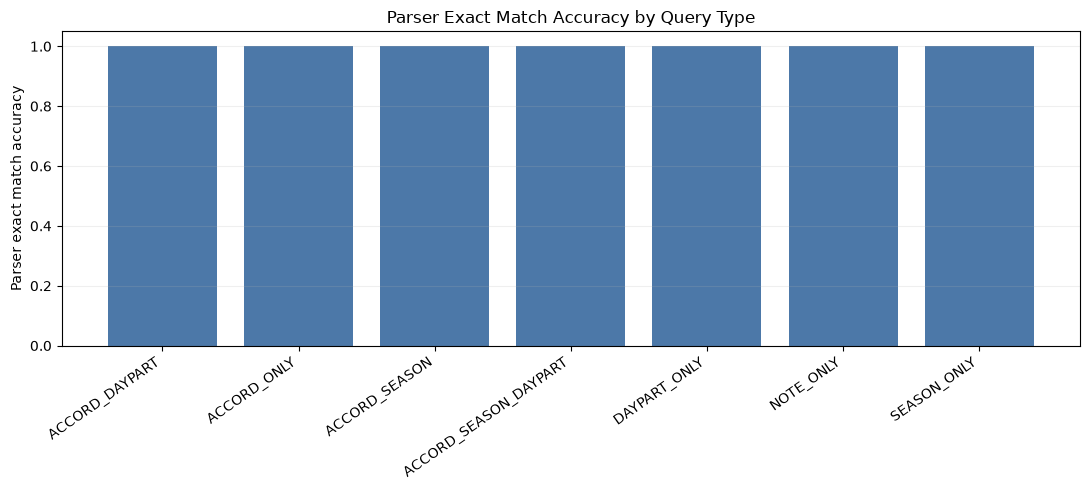

In [8]:
parser_test_rows = []
for row in synthetic_queries_df.itertuples(index=False):
    parsed = parse_query(row.query)
    accord_exact = set(parsed["accords"]) == set(row.expected_accords)
    note_exact = set(parsed["notes"]) == set(row.expected_notes)
    season_exact = set(parsed["seasons"]) == set(row.expected_seasons)
    daypart_exact = set(parsed["dayparts"]) == set(row.expected_dayparts)
    exact_match = (
        accord_exact and note_exact and season_exact and daypart_exact
        and not parsed["unresolved"]
    )
    parser_test_rows.append({
        "query_id": row.query_id,
        "query_type": row.query_type,
        "query": row.query,
        "expected_accords": json.dumps(row.expected_accords, ensure_ascii=False),
        "parsed_accords": json.dumps(parsed["accords"], ensure_ascii=False),
        "expected_notes": json.dumps(row.expected_notes, ensure_ascii=False),
        "parsed_notes": json.dumps(parsed["notes"], ensure_ascii=False),
        "expected_seasons": json.dumps(row.expected_seasons, ensure_ascii=False),
        "parsed_seasons": json.dumps(parsed["seasons"], ensure_ascii=False),
        "expected_dayparts": json.dumps(row.expected_dayparts, ensure_ascii=False),
        "parsed_dayparts": json.dumps(parsed["dayparts"], ensure_ascii=False),
        "unresolved": json.dumps(parsed["unresolved"], ensure_ascii=False),
        "accord_extraction_exact": accord_exact,
        "note_extraction_exact": note_exact,
        "season_extraction_exact": season_exact,
        "daypart_extraction_exact": daypart_exact,
        "exact_match": exact_match,
    })

parser_test_results_df = pd.DataFrame(parser_test_rows)
parser_test_results_df.to_csv(
    output_dir / "11_parser_test_results.csv", index=False, encoding="utf-8-sig"
)

parser_accuracy_by_type = (
    parser_test_results_df.groupby("query_type")["exact_match"]
    .mean().sort_index()
)
feature_accuracy = {}
expected_column_by_feature = {
    "Accord": "expected_accords", "Note": "expected_notes",
    "Season": "expected_seasons", "Daypart": "expected_dayparts",
}
exact_column_by_feature = {
    "Accord": "accord_extraction_exact", "Note": "note_extraction_exact",
    "Season": "season_extraction_exact", "Daypart": "daypart_extraction_exact",
}
for feature, expected_column in expected_column_by_feature.items():
    mask = parser_test_results_df[expected_column].ne("[]")
    feature_accuracy[feature] = parser_test_results_df.loc[
        mask, exact_column_by_feature[feature]
    ].mean()

parser_accuracy_summary = pd.Series({
    "Overall Exact Match Accuracy": parser_test_results_df["exact_match"].mean(),
    **{f"{feature} extraction accuracy": value for feature, value in feature_accuracy.items()},
})
display(parser_accuracy_summary.to_frame("accuracy"))
display(parser_accuracy_by_type.to_frame("exact_match_accuracy"))

plt.figure(figsize=(11, 5))
plt.bar(parser_accuracy_by_type.index, parser_accuracy_by_type.values, color="#4C78A8")
plt.ylim(0, 1.05)
plt.ylabel("Parser exact match accuracy")
plt.title("Parser Exact Match Accuracy by Query Type")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


## 10. UNRESOLVED와 Partial Resolution 테스트

Partial Resolution
(문장의 일부는 Feature로 이해했지만 일부 표현은 이해하지 못한 상태)에서는 해결된 Feature로 검색할 수
있지만 결과에 경고를 붙인다. Resolution Rate
(인식 대상으로 삼은 표현 중 실제 Feature로 연결된 비율)는 `resolved / (resolved + unresolved)`이다.

완전 미해결 Query는 추천을 생성하지 않는다.


In [9]:
unresolved_test_queries = [
    "포근한 향",
    "촉촉하고 깨끗한 향",
    "비 오는 숲 같은 향",
    "고급 호텔 로비 같은 향",
    "따뜻한 이불 같은 향",
]
partial_test_queries = [
    "여름에 어울리는 포근한 vanilla 향",
    "밤에 쓰기 좋은 깨끗한 woody 향",
    "봄 낮에 어울리는 촉촉한 citrus 향",
]

resolution_rows = []
for index, query in enumerate(unresolved_test_queries, start=1):
    parsed = parse_query(query)
    summary = resolution_summary(parsed)
    resolution_rows.append({
        "query_id": f"U{index:03d}", "query_type": "UNRESOLVED",
        "query": query, "status": summary["status"],
        "resolved_features": json.dumps(make_target_profile(parsed), ensure_ascii=False),
        "unresolved_expressions": json.dumps(parsed["unresolved"], ensure_ascii=False),
        "resolution_rate": summary["resolution_rate"],
        "recommendation_generated": False,
        "parser_result": json.dumps(parsed, ensure_ascii=False),
    })
for index, query in enumerate(partial_test_queries, start=1):
    parsed = parse_query(query)
    summary = resolution_summary(parsed)
    resolution_rows.append({
        "query_id": f"P{index:03d}", "query_type": "PARTIAL_RESOLUTION",
        "query": query, "status": summary["status"],
        "resolved_features": json.dumps(make_target_profile(parsed), ensure_ascii=False),
        "unresolved_expressions": json.dumps(parsed["unresolved"], ensure_ascii=False),
        "resolution_rate": summary["resolution_rate"],
        "recommendation_generated": summary["resolved_count"] > 0,
        "parser_result": json.dumps(parsed, ensure_ascii=False),
    })

unresolved_queries_df = pd.DataFrame(resolution_rows)
unresolved_queries_df.to_csv(
    output_dir / "11_unresolved_queries.csv", index=False, encoding="utf-8-sig"
)
display(unresolved_queries_df)

assert unresolved_queries_df.loc[
    unresolved_queries_df["query_type"].eq("UNRESOLVED"), "status"
].eq("UNRESOLVED").all()
assert unresolved_queries_df.loc[
    unresolved_queries_df["query_type"].eq("PARTIAL_RESOLUTION"), "status"
].eq("PARTIALLY_RESOLVED").all()


,query_id,query_type,query,status,resolved_features,unresolved_expressions,resolution_rate,recommendation_generated,parser_result
0,U001,UNRESOLVED,포근한 향,UNRESOLVED,"{""accords"": {}, ""notes"": {}, ""season"": {}, ""da...","[""포근한""]",0.000000,False,"{""accords"": [], ""notes"": [], ""seasons"": [], ""d..."
1,U002,UNRESOLVED,촉촉하고 깨끗한 향,UNRESOLVED,"{""accords"": {}, ""notes"": {}, ""season"": {}, ""da...","[""촉촉한"", ""깨끗한""]",0.000000,False,"{""accords"": [], ""notes"": [], ""seasons"": [], ""d..."
2,U003,UNRESOLVED,비 오는 숲 같은 향,UNRESOLVED,"{""accords"": {}, ""notes"": {}, ""season"": {}, ""da...","[""비 오는 숲""]",0.000000,False,"{""accords"": [], ""notes"": [], ""seasons"": [], ""d..."
3,U004,UNRESOLVED,고급 호텔 로비 같은 향,UNRESOLVED,"{""accords"": {}, ""notes"": {}, ""season"": {}, ""da...","[""고급 호텔 로비""]",0.000000,False,"{""accords"": [], ""notes"": [], ""seasons"": [], ""d..."
4,U005,UNRESOLVED,따뜻한 이불 같은 향,UNRESOLVED,"{""accords"": {}, ""notes"": {}, ""season"": {}, ""da...","[""따뜻한 이불""]",0.000000,False,"{""accords"": [], ""notes"": [], ""seasons"": [], ""d..."
5,P001,PARTIAL_RESOLUTION,여름에 어울리는 포근한 vanilla 향,PARTIALLY_RESOLVED,"{""accords"": {""vanilla"": 1.0}, ""notes"": {}, ""se...","[""포근한""]",0.666667,True,"{""accords"": [""vanilla""], ""notes"": [], ""seasons..."
6,P002,PARTIAL_RESOLUTION,밤에 쓰기 좋은 깨끗한 woody 향,PARTIALLY_RESOLVED,"{""accords"": {""woody"": 1.0}, ""notes"": {}, ""seas...","[""깨끗한""]",0.666667,True,"{""accords"": [""woody""], ""notes"": [], ""seasons"":..."
7,P003,PARTIAL_RESOLUTION,봄 낮에 어울리는 촉촉한 citrus 향,PARTIALLY_RESOLVED,"{""accords"": {""citrus"": 1.0}, ""notes"": {}, ""sea...","[""촉촉한""]",0.750000,True,"{""accords"": [""citrus""], ""notes"": [], ""seasons""..."


## 11. Retrieval 실행과 Template 설명

전체 향수에서 Final Baseline Score를 계산하고 각 해결 가능한 Query의 TOP 10을 선택한다. 동점은
Final Score, Coverage, Base Match, perfume ID 순으로 고정하며 popularity는 정렬에 쓰지 않는다.

Template
(미리 정해 놓은 문장 형식) 설명은 실제 계산에 사용한 Accord strength, Note 존재, Season share,
Daypart share만 말한다. Partial Resolution 결과에는 미해결 표현 경고를 붙인다.


In [10]:
valid_popularity = popularity_values[np.isfinite(popularity_values)]
popularity_cutoffs = np.quantile(valid_popularity, [0.25, 0.50, 0.75])
popularity_quartiles = np.full(n_perfumes, "UNKNOWN", dtype=object)
valid_popularity_mask = np.isfinite(popularity_values)
popularity_quartiles[valid_popularity_mask] = [
    f"Q{index + 1}"
    for index in np.searchsorted(
        popularity_cutoffs,
        popularity_values[valid_popularity_mask],
        side="right",
    )
]
corpus_median_popularity = float(np.median(valid_popularity))


def cell_value(matrix, row_index, column_index):
    return float(matrix[row_index, column_index])


def make_explanation(perfume_row, parsed, partial=False):
    details = []
    if parsed["accords"]:
        values = [
            cell_value(accord_strength_matrix, perfume_row, accord_to_col[name])
            for name in parsed["accords"]
        ]
        details.append(", ".join(
            f"{name} Accord 강도 {value:.0f}점"
            for name, value in zip(parsed["accords"], values)
        ))
    if parsed["notes"]:
        values = [
            cell_value(note_presence_matrix, perfume_row, note_to_col[name]) > 0
            for name in parsed["notes"]
        ]
        details.append(", ".join(
            f"{name} Note {'포함' if present else '미포함'}"
            for name, present in zip(parsed["notes"], values)
        ))
    if parsed["seasons"]:
        values = [season_matrix[perfume_row, season_to_col[name]] for name in parsed["seasons"]]
        details.append(", ".join(
            f"커뮤니티 {name} {value:.0%}" if np.isfinite(value) else f"{name} 정보 UNKNOWN"
            for name, value in zip(parsed["seasons"], values)
        ))
    if parsed["dayparts"]:
        values = [daypart_matrix[perfume_row, daypart_to_col[name]] for name in parsed["dayparts"]]
        details.append(", ".join(
            f"커뮤니티 {name} {value:.0%}" if np.isfinite(value) else f"{name} 정보 UNKNOWN"
            for name, value in zip(parsed["dayparts"], values)
        ))
    prefix = "일부 표현을 해석하지 못했습니다. 해결된 조건만 사용했으며, " if partial else ""
    return prefix + "이 향수의 계산 근거는 " + ", ".join(details) + "입니다."


def retrieve_query(query_id, query_type, query, parsed, top_k=10):
    summary = resolution_summary(parsed)
    if summary["status"] == "UNRESOLVED":
        return []
    scores = score_query(parsed)
    candidate_rows = np.argpartition(-scores["final_score"], top_k - 1)[:top_k]
    order = np.lexsort((
        perfume_ids[candidate_rows],
        -np.nan_to_num(scores["base_match_score"][candidate_rows], nan=-1.0),
        -scores["evidence_coverage"][candidate_rows],
        -scores["final_score"][candidate_rows],
    ))
    ranked_rows = candidate_rows[order]
    output = []
    for rank, perfume_row in enumerate(ranked_rows, start=1):
        output.append({
            "query_id": query_id,
            "query_type": query_type,
            "query": query,
            "resolution_status": summary["status"],
            "resolution_rate": summary["resolution_rate"],
            "rank": rank,
            "perfume_id": int(perfume_ids[perfume_row]),
            "name": perfume_names[perfume_row],
            "brand": perfume_brands[perfume_row],
            "final_score": scores["final_score"][perfume_row],
            "base_match_score": scores["base_match_score"][perfume_row],
            "evidence_coverage": scores["evidence_coverage"][perfume_row],
            "accord_match": scores["accord_match"][perfume_row],
            "note_match": scores["note_match"][perfume_row],
            "season_match": scores["season_match"][perfume_row],
            "daypart_match": scores["daypart_match"][perfume_row],
            "popularity_magnitude": popularity_values[perfume_row],
            "popularity_quartile": popularity_quartiles[perfume_row],
            "explanation": make_explanation(
                perfume_row, parsed, partial=summary["status"] == "PARTIALLY_RESOLVED"
            ),
            "perfume_row_index": int(perfume_row),
        })
    return output


recommendation_rows = []
parsed_by_query_id = {}
query_meta_by_id = {}
for row in synthetic_queries_df.itertuples(index=False):
    parsed = parse_query(row.query)
    parsed_by_query_id[row.query_id] = parsed
    query_meta_by_id[row.query_id] = {"query_type": row.query_type, "query": row.query}
    recommendation_rows.extend(
        retrieve_query(row.query_id, row.query_type, row.query, parsed)
    )
for row in unresolved_queries_df[
    unresolved_queries_df["query_type"].eq("PARTIAL_RESOLUTION")
].itertuples(index=False):
    parsed = parse_query(row.query)
    parsed_by_query_id[row.query_id] = parsed
    query_meta_by_id[row.query_id] = {"query_type": row.query_type, "query": row.query}
    recommendation_rows.extend(
        retrieve_query(row.query_id, row.query_type, row.query, parsed)
    )

recommendations_internal_df = pd.DataFrame(recommendation_rows)
print(f"Retrieval을 실행한 Query 수: {recommendations_internal_df['query_id'].nunique():,}")
print(f"TOP 10 결과 행 수: {len(recommendations_internal_df):,}")
display(recommendations_internal_df.groupby("query_type").size().to_frame("recommendation_rows"))
display(recommendations_internal_df.head(30).drop(columns=["perfume_row_index"]))


Retrieval을 실행한 Query 수: 129
TOP 10 결과 행 수: 1,290


,recommendation_rows
query_type,
ACCORD_DAYPART,200
ACCORD_ONLY,300
ACCORD_SEASON,200
ACCORD_SEASON_DAYPART,200
DAYPART_ONLY,20
NOTE_ONLY,300
PARTIAL_RESOLUTION,30
SEASON_ONLY,40


,query_id,query_type,query,resolution_status,resolution_rate,rank,perfume_id,name,brand,final_score,base_match_score,evidence_coverage,accord_match,note_match,season_match,daypart_match,popularity_magnitude,popularity_quartile,explanation
0,Q001,ACCORD_ONLY,woody 향,RESOLVED,1.000000,1,9,Eau des Merveilles,Hermès,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,"28,057.000000",Q4,이 향수의 계산 근거는 woody Accord 강도 100점입니다.
1,Q001,ACCORD_ONLY,woody 향,RESOLVED,1.000000,2,10,Parfum des Merveilles,Hermès,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,"1,192.000000",Q4,이 향수의 계산 근거는 woody Accord 강도 100점입니다.
2,Q001,ACCORD_ONLY,woody 향,RESOLVED,1.000000,3,21,Rouge Hermès,Hermès,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,"4,645.000000",Q4,이 향수의 계산 근거는 woody Accord 강도 100점입니다.
3,Q001,ACCORD_ONLY,woody 향,RESOLVED,1.000000,4,34,Very Irresistible for men,Givenchy,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,"6,544.000000",Q4,이 향수의 계산 근거는 woody Accord 강도 100점입니다.
4,Q001,ACCORD_ONLY,woody 향,RESOLVED,1.000000,5,36,Ysatis,Givenchy,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,"12,904.000000",Q4,이 향수의 계산 근거는 woody Accord 강도 100점입니다.
5,Q001,ACCORD_ONLY,woody 향,RESOLVED,1.000000,6,83256,No. 04 Pour Femme,Marquisa Dubai,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,39.000000,Q2,이 향수의 계산 근거는 woody Accord 강도 100점입니다.
6,Q001,ACCORD_ONLY,woody 향,RESOLVED,1.000000,7,83327,Atelier X-Berg,Hoermanseder,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,41.000000,Q2,이 향수의 계산 근거는 woody Accord 강도 100점입니다.
7,Q001,ACCORD_ONLY,woody 향,RESOLVED,1.000000,8,83330,Tobacco & Oud,ABD Malik,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,12.000000,Q1,이 향수의 계산 근거는 woody Accord 강도 100점입니다.
8,Q001,ACCORD_ONLY,woody 향,RESOLVED,1.000000,9,120251,Silk Spirit,The Exceptional,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,17.000000,Q1,이 향수의 계산 근거는 woody Accord 강도 100점입니다.
9,Q001,ACCORD_ONLY,woody 향,RESOLVED,1.000000,10,120252,Limitless Sky,The Perfumist Ici ParisXL,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,17.000000,Q1,이 향수의 계산 근거는 woody Accord 강도 100점입니다.


## 12. Query Condition Satisfaction

Diagnostic
(최종 품질을 평가하기보다 규칙이 의도대로 동작하는지 확인하는 진단) threshold는 다음과 같다.

- Accord: 모든 요청 Accord strength가 50 이상
- Note: 모든 요청 Note가 존재
- Season: 요청 season share가 네 계절 중 최고이며 reliable
- Daypart: 요청 daypart share가 day/night 중 최고이며 reliable

Condition Satisfaction Rate
(TOP 10 결과가 문장에 명시된 모든 조건을 데이터상 만족한 비율)를 계산한다. 추천 정확도가 아니다.
`UNKNOWN` context는 만족으로 세지 않는다.


In [11]:
def all_conditions_satisfied(perfume_row, parsed):
    conditions = []
    for accord in parsed["accords"]:
        conditions.append(
            cell_value(accord_strength_matrix, perfume_row, accord_to_col[accord]) >= 50
        )
    for note in parsed["notes"]:
        conditions.append(
            cell_value(note_presence_matrix, perfume_row, note_to_col[note]) > 0
        )
    for season in parsed["seasons"]:
        row = season_matrix[perfume_row]
        value = row[season_to_col[season]]
        conditions.append(
            bool(np.isfinite(value) and np.isclose(value, np.nanmax(row)))
        )
    for daypart in parsed["dayparts"]:
        row = daypart_matrix[perfume_row]
        value = row[daypart_to_col[daypart]]
        conditions.append(
            bool(np.isfinite(value) and np.isclose(value, np.nanmax(row)))
        )
    return bool(conditions and all(conditions))


recommendations_internal_df["all_conditions_satisfied"] = [
    all_conditions_satisfied(
        row.perfume_row_index,
        parsed_by_query_id[row.query_id],
    )
    for row in recommendations_internal_df.itertuples(index=False)
]

recommendations_df = recommendations_internal_df.drop(columns=["perfume_row_index"])
recommendations_df.to_csv(
    output_dir / "11_rule_baseline_recommendations.csv",
    index=False,
    encoding="utf-8-sig",
)


## 13. Query별 동작 진단

Accord-only는 TOP 10 요청 strength 평균을 0을 포함한 전체 코퍼스 평균과 비교한다. Accord가 실제 주요
목록에 있는 향수만의 조건부 평균도 함께 남긴다. Note-only는 TOP 10 보유율, Season/Daypart-only는
reliable 코퍼스 평균과 비교한다. 복합 Query는 각 조건과 Coverage를 따로 확인한다.


In [12]:
def corpus_category_values(parsed):
    values = {
        "accord": np.nan, "accord_when_present": np.nan,
        "note": np.nan, "season": np.nan, "daypart": np.nan,
    }
    if parsed["accords"]:
        columns = [accord_to_col[name] for name in parsed["accords"]]
        score = mean_sparse_columns(accord_strength_matrix, columns, scale=100.0)
        values["accord"] = float(score.mean())
        values["accord_when_present"] = float(score[score > 0].mean()) if (score > 0).any() else np.nan
    if parsed["notes"]:
        columns = [note_to_col[name] for name in parsed["notes"]]
        values["note"] = float(mean_sparse_columns(note_presence_matrix, columns).mean())
    if parsed["seasons"]:
        columns = [season_to_col[name] for name in parsed["seasons"]]
        submatrix = season_matrix[:, columns]
        reliable = np.isfinite(submatrix).all(axis=1)
        values["season"] = float(submatrix[reliable].mean())
    if parsed["dayparts"]:
        columns = [daypart_to_col[name] for name in parsed["dayparts"]]
        submatrix = daypart_matrix[:, columns]
        reliable = np.isfinite(submatrix).all(axis=1)
        values["daypart"] = float(submatrix[reliable].mean())
    return values


diagnostic_rows = []
for query_id, top10 in recommendations_internal_df.groupby("query_id", sort=False):
    parsed = parsed_by_query_id[query_id]
    corpus_values = corpus_category_values(parsed)
    meta = query_meta_by_id[query_id]
    diagnostic_rows.append({
        "query_id": query_id,
        "query_type": meta["query_type"],
        "query": meta["query"],
        "resolution_status": resolution_summary(parsed)["status"],
        "condition_satisfaction_rate": top10["all_conditions_satisfied"].mean(),
        "evidence_coverage_mean": top10["evidence_coverage"].mean(),
        "final_score_mean": top10["final_score"].mean(),
        "top10_requested_accord_strength_mean": top10["accord_match"].mean() * 100,
        "corpus_requested_accord_strength_mean": corpus_values["accord"] * 100,
        "corpus_requested_accord_strength_when_present": corpus_values["accord_when_present"] * 100,
        "top10_requested_note_presence_rate": top10["note_match"].mean(),
        "corpus_requested_note_presence_rate": corpus_values["note"],
        "top10_requested_season_share_mean": top10["season_match"].mean(),
        "corpus_requested_season_share_mean": corpus_values["season"],
        "top10_requested_daypart_share_mean": top10["daypart_match"].mean(),
        "corpus_requested_daypart_share_mean": corpus_values["daypart"],
        "top10_median_popularity": top10["popularity_magnitude"].median(),
    })

query_diagnostics_df = pd.DataFrame(diagnostic_rows)
query_diagnostics_df.to_csv(
    output_dir / "11_query_diagnostics.csv", index=False, encoding="utf-8-sig"
)

accord_validation_df = query_diagnostics_df[
    query_diagnostics_df["query_type"].eq("ACCORD_ONLY")
][[
    "query", "top10_requested_accord_strength_mean",
    "corpus_requested_accord_strength_mean",
    "corpus_requested_accord_strength_when_present",
]]
note_validation_df = query_diagnostics_df[
    query_diagnostics_df["query_type"].eq("NOTE_ONLY")
][[
    "query", "top10_requested_note_presence_rate",
    "corpus_requested_note_presence_rate",
]]
season_validation_df = query_diagnostics_df[
    query_diagnostics_df["query_type"].eq("SEASON_ONLY")
][[
    "query", "top10_requested_season_share_mean",
    "corpus_requested_season_share_mean",
]]
daypart_validation_df = query_diagnostics_df[
    query_diagnostics_df["query_type"].eq("DAYPART_ONLY")
][[
    "query", "top10_requested_daypart_share_mean",
    "corpus_requested_daypart_share_mean",
]]
complex_validation_df = query_diagnostics_df[
    query_diagnostics_df["query_type"].isin([
        "ACCORD_SEASON", "ACCORD_DAYPART", "ACCORD_SEASON_DAYPART"
    ])
][[
    "query_type", "query", "top10_requested_accord_strength_mean",
    "top10_requested_season_share_mean", "top10_requested_daypart_share_mean",
    "evidence_coverage_mean", "condition_satisfaction_rate",
]]

display(Markdown("### Accord-only 검증"))
display(accord_validation_df)
display(Markdown("### Note-only 검증"))
display(note_validation_df)
display(Markdown("### Season-only 검증"))
display(season_validation_df)
display(Markdown("### Daypart-only 검증"))
display(daypart_validation_df)
display(Markdown("### 복합 Query 조건별 검증"))
display(complex_validation_df)


### Accord-only 검증

,query,top10_requested_accord_strength_mean,corpus_requested_accord_strength_mean,corpus_requested_accord_strength_when_present
0,woody 향,100.000000,40.631661,65.828359
1,powdery 향,100.000000,23.042969,48.343149
2,sweet 향,100.000000,24.967241,54.332829
3,citrus 향,100.000000,30.583620,67.283052
4,aromatic 향,100.000000,23.205625,56.065595
5,fresh spicy 향,100.000000,18.329334,51.155871
6,floral 향,100.000000,19.855173,56.229186
7,amber 향,100.000000,21.034928,61.021549
8,warm spicy 향,100.000000,19.613712,57.098281
9,fruity 향,100.000000,21.120904,64.469045


### Note-only 검증

,query,top10_requested_note_presence_rate,corpus_requested_note_presence_rate
30,Musk 노트가 느껴지는 향,1.000000,0.373259
31,Amber 노트가 느껴지는 향,1.000000,0.277958
32,Bergamot 노트가 느껴지는 향,1.000000,0.275426
33,Vanilla 노트가 느껴지는 향,1.000000,0.270052
34,Sandalwood 노트가 느껴지는 향,1.000000,0.259926
35,Jasmine 노트가 느껴지는 향,1.000000,0.255332
36,Patchouli 노트가 느껴지는 향,1.000000,0.246138
37,Rose 노트가 느껴지는 향,1.000000,0.210748
38,Cedar 노트가 느껴지는 향,1.000000,0.169067
39,Vetiver 노트가 느껴지는 향,1.000000,0.133965


### Season-only 검증

,query,top10_requested_season_share_mean,corpus_requested_season_share_mean
60,겨울 향,0.745092,0.210156
61,봄 향,0.752243,0.285781
62,여름 향,0.820811,0.238738
63,가을 향,0.732678,0.265324


### Daypart-only 검증

,query,top10_requested_daypart_share_mean,corpus_requested_daypart_share_mean
64,낮에 쓰기 좋은 향,1.000000,0.620056
65,밤에 쓰기 좋은 향,0.935743,0.379944


### 복합 Query 조건별 검증

,query_type,query,top10_requested_accord_strength_mean,top10_requested_season_share_mean,top10_requested_daypart_share_mean,evidence_coverage_mean,condition_satisfaction_rate
66,ACCORD_SEASON,가을에 어울리는 woody 향,98.700000,0.634993,NaN,1.000000,1.000000
67,ACCORD_DAYPART,밤에 어울리는 woody 향,99.900000,NaN,0.898054,1.000000,1.000000
68,ACCORD_SEASON_DAYPART,가을 밤에 어울리는 woody 향,99.600000,0.430314,0.851318,1.000000,0.400000
69,ACCORD_SEASON,겨울에 어울리는 powdery 향,96.300000,0.553025,NaN,1.000000,1.000000
70,ACCORD_DAYPART,밤에 어울리는 powdery 향,99.600000,NaN,0.792125,1.000000,1.000000
71,ACCORD_SEASON_DAYPART,겨울 밤에 어울리는 powdery 향,92.399999,0.539587,0.807109,1.000000,1.000000
72,ACCORD_SEASON,겨울에 어울리는 sweet 향,98.100000,0.645161,NaN,1.000000,1.000000
73,ACCORD_DAYPART,밤에 어울리는 sweet 향,98.900000,NaN,0.902344,1.000000,1.000000
74,ACCORD_SEASON_DAYPART,겨울 밤에 어울리는 sweet 향,96.000000,0.563832,0.913358,1.000000,1.000000
75,ACCORD_SEASON,여름에 어울리는 citrus 향,100.000000,0.782583,NaN,1.000000,1.000000


## 14. Query Type별 Condition Satisfaction과 Evidence Coverage

Query Type별 TOP 10의 평균을 비교한다. Accord/Note-only의 Evidence Coverage는 직접 관측 category만
사용하므로 1이어야 한다. Community context가 포함되면 reliable vote가 없는 향수에서 Coverage가 낮아진다.


,query_count,condition_satisfaction_rate,evidence_coverage,median_top10_popularity
query_type,,,,
ACCORD_DAYPART,20,1.000000,1.000000,389.500000
ACCORD_ONLY,30,1.000000,1.000000,103.250000
ACCORD_SEASON,20,0.975000,1.000000,324.750000
ACCORD_SEASON_DAYPART,20,0.910000,1.000000,391.250000
DAYPART_ONLY,2,1.000000,1.000000,264.000000
NOTE_ONLY,30,1.000000,1.000000,336.250000
PARTIAL_RESOLUTION,3,1.000000,1.000000,351.500000
SEASON_ONLY,4,1.000000,1.000000,421.000000


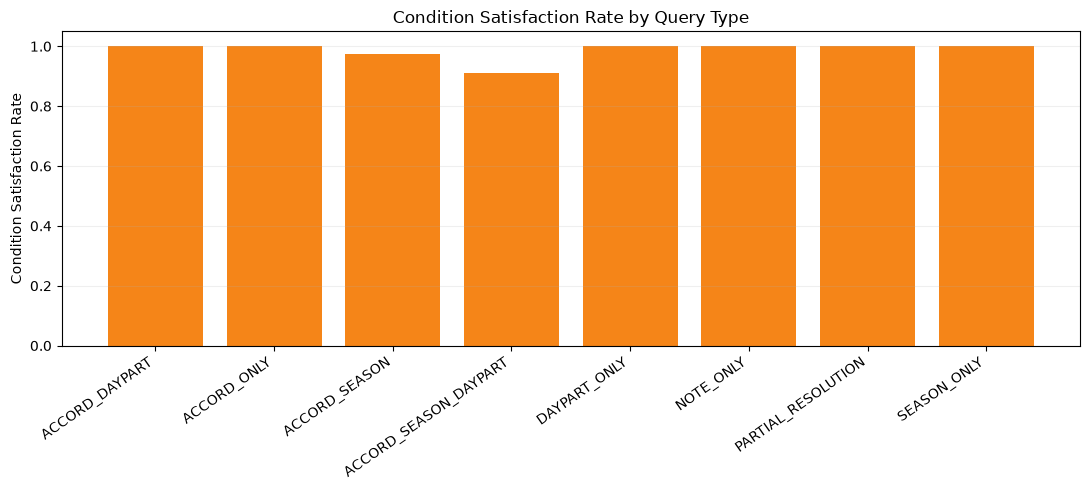

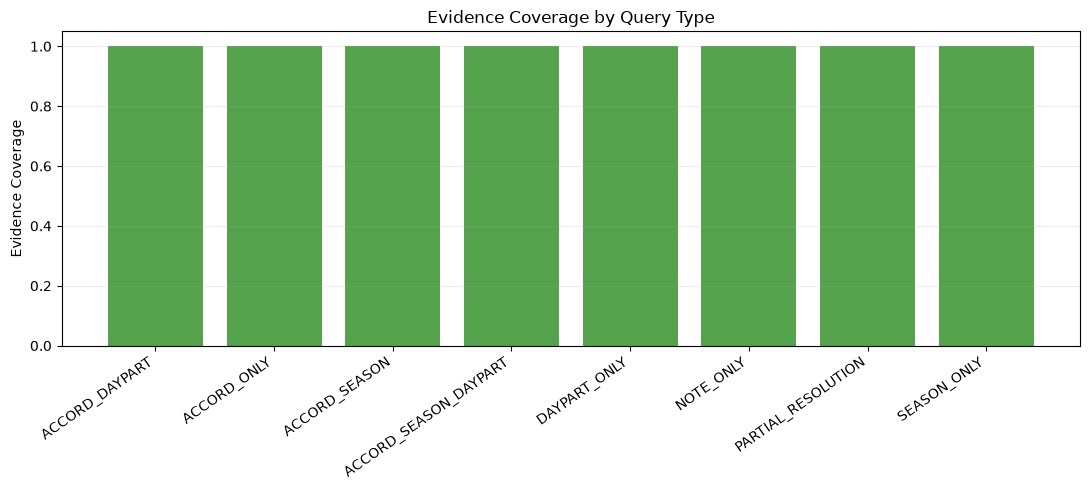

In [13]:
diagnostic_by_type = query_diagnostics_df.groupby("query_type").agg(
    query_count=("query_id", "count"),
    condition_satisfaction_rate=("condition_satisfaction_rate", "mean"),
    evidence_coverage=("evidence_coverage_mean", "mean"),
    median_top10_popularity=("top10_median_popularity", "median"),
).sort_index()
display(diagnostic_by_type)

for column, title, color in [
    ("condition_satisfaction_rate", "Condition Satisfaction Rate by Query Type", "#F58518"),
    ("evidence_coverage", "Evidence Coverage by Query Type", "#54A24B"),
]:
    plt.figure(figsize=(11, 5))
    plt.bar(diagnostic_by_type.index, diagnostic_by_type[column], color=color)
    plt.ylim(0, 1.05)
    plt.ylabel(column.replace("_", " ").title())
    plt.title(title)
    plt.xticks(rotation=35, ha="right")
    plt.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    plt.show()


## 15. Season / Daypart Query 시각 진단

Context-only TOP 10의 요청 share 평균과 전체 reliable 향수 평균을 나란히 비교한다.


C:\Users\SSAFY\AppData\Local\Temp\ipykernel_20456\3464355229.py:9: UserWarning: Glyph 44200 (\N{HANGUL SYLLABLE GYEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_20456\3464355229.py:9: UserWarning: Glyph 50872 (\N{HANGUL SYLLABLE UL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_20456\3464355229.py:9: UserWarning: Glyph 54693 (\N{HANGUL SYLLABLE HYANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_20456\3464355229.py:9: UserWarning: Glyph 48388 (\N{HANGUL SYLLABLE BOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_20456\3464355229.py:9: UserWarning: Glyph 50668 (\N{HANGUL SYLLABLE YEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_20456\3464355229.py:9: UserWarning: Glyph 47492 (\N{HANGUL SYLLABLE REUM}) missing from f

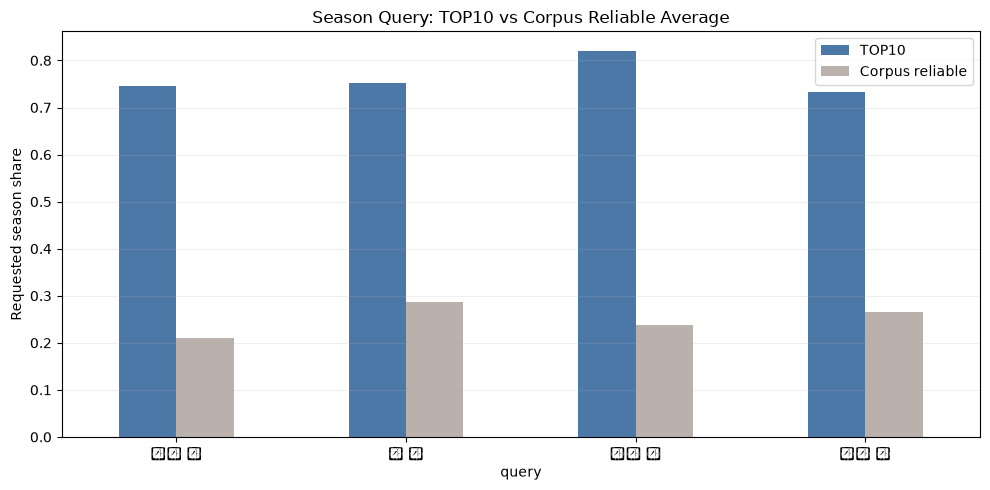

C:\Users\SSAFY\AppData\Local\Temp\ipykernel_20456\3464355229.py:20: UserWarning: Glyph 45230 (\N{HANGUL SYLLABLE NAJ}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_20456\3464355229.py:20: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_20456\3464355229.py:20: UserWarning: Glyph 50416 (\N{HANGUL SYLLABLE SSEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_20456\3464355229.py:20: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_20456\3464355229.py:20: UserWarning: Glyph 51339 (\N{HANGUL SYLLABLE JOH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_20456\3464355229.py:20: UserWarning: Glyph 51008 (\N{HANGUL SYLLABLE EUN}) missing from 

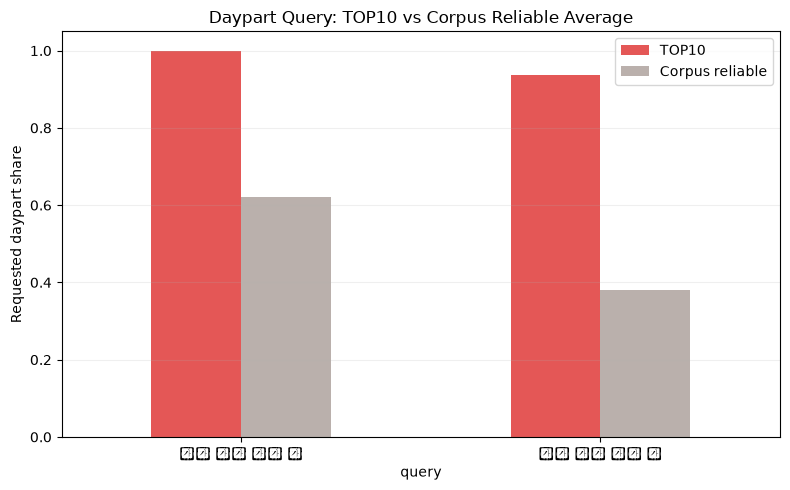

In [14]:
season_plot = season_validation_df.set_index("query")[[]].copy()
season_plot["TOP10"] = season_validation_df.set_index("query")["top10_requested_season_share_mean"]
season_plot["Corpus reliable"] = season_validation_df.set_index("query")["corpus_requested_season_share_mean"]
season_plot.plot(kind="bar", figsize=(10, 5), color=["#4C78A8", "#BAB0AC"])
plt.ylabel("Requested season share")
plt.title("Season Query: TOP10 vs Corpus Reliable Average")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

daypart_plot = daypart_validation_df.set_index("query")[[]].copy()
daypart_plot["TOP10"] = daypart_validation_df.set_index("query")["top10_requested_daypart_share_mean"]
daypart_plot["Corpus reliable"] = daypart_validation_df.set_index("query")["corpus_requested_daypart_share_mean"]
daypart_plot.plot(kind="bar", figsize=(8, 5), color=["#E45756", "#BAB0AC"])
plt.ylabel("Requested daypart share")
plt.title("Daypart Query: TOP10 vs Corpus Reliable Average")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


## 16. Evidence Coverage의 Popularity Quartile 진단

Quartile
(값을 크기순으로 네 그룹으로 나눈 것)은 `popularity.magnitude`의 전체 유효 분포로 고정한다. 각 Query
Type TOP 10에서 quartile별 Evidence Coverage를 확인한다. popularity는 Score와 rank에 사용되지 않았다.


In [15]:
coverage_by_popularity_quartile = (
    recommendations_df.groupby(
        ["query_type", "popularity_quartile"], dropna=False
    ).agg(
        result_count=("perfume_id", "count"),
        mean_evidence_coverage=("evidence_coverage", "mean"),
    ).reset_index()
)
display(pd.DataFrame({
    "boundary": ["Q1/Q2", "Q2/Q3", "Q3/Q4"],
    "popularity_magnitude": popularity_cutoffs,
}))
display(coverage_by_popularity_quartile)


,boundary,popularity_magnitude
0,Q1/Q2,22.000000
1,Q2/Q3,87.000000
2,Q3/Q4,384.000000


,query_type,popularity_quartile,result_count,mean_evidence_coverage
0,ACCORD_DAYPART,Q2,2,1.000000
1,ACCORD_DAYPART,Q3,100,1.000000
2,ACCORD_DAYPART,Q4,98,1.000000
3,ACCORD_ONLY,Q1,74,1.000000
4,ACCORD_ONLY,Q2,76,1.000000
5,ACCORD_ONLY,Q3,70,1.000000
6,ACCORD_ONLY,Q4,80,1.000000
7,ACCORD_SEASON,Q2,4,1.000000
8,ACCORD_SEASON,Q3,115,1.000000
9,ACCORD_SEASON,Q4,81,1.000000


## 17. Popularity Bias 가능성 진단

Popularity Bias
(인기 향수에 community 정보가 많아 결과가 인기 향수에 지나치게 몰릴 가능성)는 전체 median과 결과
median의 차이만 관찰한다. 이 분석만으로 bias가 있다고 단정하지 않는다.


,popularity_magnitude
Corpus median popularity,87.000000
All recommendation rows median popularity,315.000000
Community context query rows median popularity,363.000000


,top10_median_popularity
query_type,
ACCORD_DAYPART,378.000000
ACCORD_ONLY,88.000000
ACCORD_SEASON,326.500000
ACCORD_SEASON_DAYPART,424.500000
DAYPART_ONLY,270.500000
NOTE_ONLY,345.000000
PARTIAL_RESOLUTION,370.500000
SEASON_ONLY,395.500000


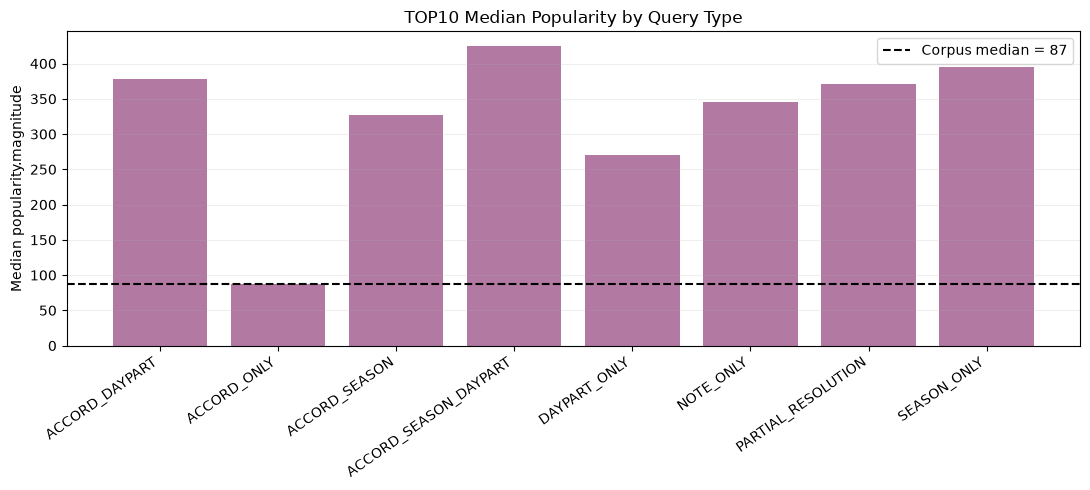

In [16]:
popularity_by_type = (
    recommendations_df.groupby("query_type")["popularity_magnitude"]
    .median().sort_index()
)
overall_recommendation_median_popularity = float(
    recommendations_df["popularity_magnitude"].median()
)
context_query_types = [
    query_type for query_type in popularity_by_type.index
    if "SEASON" in query_type or "DAYPART" in query_type
    or query_type in ("SEASON_ONLY", "DAYPART_ONLY")
]
context_recommendation_median_popularity = float(
    recommendations_df[
        recommendations_df["query_type"].isin(context_query_types)
    ]["popularity_magnitude"].median()
)

popularity_summary = pd.Series({
    "Corpus median popularity": corpus_median_popularity,
    "All recommendation rows median popularity": overall_recommendation_median_popularity,
    "Community context query rows median popularity": context_recommendation_median_popularity,
})
display(popularity_summary.to_frame("popularity_magnitude"))
display(popularity_by_type.to_frame("top10_median_popularity"))

plt.figure(figsize=(11, 5))
plt.bar(popularity_by_type.index, popularity_by_type.values, color="#B279A2")
plt.axhline(
    corpus_median_popularity, color="black", linestyle="--",
    label=f"Corpus median = {corpus_median_popularity:,.0f}",
)
plt.ylabel("Median popularity.magnitude")
plt.title("TOP10 Median Popularity by Query Type")
plt.xticks(rotation=35, ha="right")
plt.legend()
plt.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()


## 18. 대표 추천 사례

각 유형에서 최소 두 Query를 골라 Parser → Target Profile → TOP 5 Feature Score → Template 설명 순서로
출력한다. UNRESOLVED는 추천을 만들지 않는다.


In [17]:
representative_types = [
    "ACCORD_ONLY", "NOTE_ONLY", "SEASON_ONLY", "DAYPART_ONLY",
    "ACCORD_SEASON", "ACCORD_SEASON_DAYPART", "PARTIAL_RESOLUTION",
]
representative_columns = [
    "rank", "perfume_id", "name", "brand", "final_score",
    "base_match_score", "evidence_coverage", "accord_match", "note_match",
    "season_match", "daypart_match", "explanation",
]
for query_type in representative_types:
    query_ids = (
        recommendations_df[recommendations_df["query_type"].eq(query_type)]["query_id"]
        .drop_duplicates().head(2).tolist()
    )
    for query_id in query_ids:
        meta = query_meta_by_id[query_id]
        parsed = parsed_by_query_id[query_id]
        display(Markdown(f"### {query_type}: `{meta['query']}`"))
        print("Parser result")
        print(json.dumps(parsed, ensure_ascii=False, indent=2))
        print("Target Profile")
        print(json.dumps(make_target_profile(parsed), ensure_ascii=False, indent=2))
        display(
            recommendations_df[recommendations_df["query_id"].eq(query_id)]
            .head(5)[representative_columns]
        )

for row in unresolved_queries_df[
    unresolved_queries_df["query_type"].eq("UNRESOLVED")
].head(2).itertuples(index=False):
    display(Markdown(f"### UNRESOLVED: `{row.query}`"))
    print("Parser result")
    print(json.dumps(parse_query(row.query), ensure_ascii=False, indent=2))
    print("status = UNRESOLVED; recommendation_generated = False")


### ACCORD_ONLY: `woody 향`

Parser result
{
  "accords": [
    "woody"
  ],
  "notes": [],
  "seasons": [],
  "dayparts": [],
  "unresolved": []
}
Target Profile
{
  "accords": {
    "woody": 1.0
  },
  "notes": {},
  "season": {},
  "daypart": {}
}


,rank,perfume_id,name,brand,final_score,base_match_score,evidence_coverage,accord_match,note_match,season_match,daypart_match,explanation
0,1,9,Eau des Merveilles,Hermès,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,이 향수의 계산 근거는 woody Accord 강도 100점입니다.
1,2,10,Parfum des Merveilles,Hermès,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,이 향수의 계산 근거는 woody Accord 강도 100점입니다.
2,3,21,Rouge Hermès,Hermès,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,이 향수의 계산 근거는 woody Accord 강도 100점입니다.
3,4,34,Very Irresistible for men,Givenchy,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,이 향수의 계산 근거는 woody Accord 강도 100점입니다.
4,5,36,Ysatis,Givenchy,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,이 향수의 계산 근거는 woody Accord 강도 100점입니다.


### ACCORD_ONLY: `powdery 향`

Parser result
{
  "accords": [
    "powdery"
  ],
  "notes": [],
  "seasons": [],
  "dayparts": [],
  "unresolved": []
}
Target Profile
{
  "accords": {
    "powdery": 1.0
  },
  "notes": {},
  "season": {},
  "daypart": {}
}


...

### UNRESOLVED: `포근한 향`

Parser result
{
  "accords": [],
  "notes": [],
  "seasons": [],
  "dayparts": [],
  "unresolved": [
    "포근한"
  ]
}
status = UNRESOLVED; recommendation_generated = False


### UNRESOLVED: `촉촉하고 깨끗한 향`

Parser result


{
  "accords": [],
  "notes": [],
  "seasons": [],
  "dayparts": [],
  "unresolved": [
    "촉촉한",
    "깨끗한"
  ]
}
status = UNRESOLVED; recommendation_generated = False


## 19. 현재 Baseline의 한계

1. 데이터의 명확한 Feature 이름과 제한적인 직접 별칭만 처리할 수 있다.
2. `포근한`, `촉촉한`, `비 오는 숲` 같은 Semantic Expression
   (단어 자체뿐 아니라 문맥과 이미지까지 이해해야 하는 표현)은 처리하지 못한다.
3. category 평균과 Coverage 곱셈은 사람의 만족도를 기준으로 최적화된 weight가 아니다.
4. Season / Daypart 데이터가 없는 향수는 Evidence Coverage가 낮아진다.
5. Golden Set이 없으므로 이번 결과를 추천 정확도라고 표현할 수 없다.
6. 한국어 Accord / Note 별칭 사전은 단순 번역·음차 일부로 제한되어 있다.

Condition Satisfaction, Parser Exact Match, 분포 비교는 규칙의 동작 진단이다. 사용자가 실제 결과를
좋아하는지 또는 더 관련 있다고 판단하는지를 측정하지 않는다.


## 20. 결과 파일 검증

요구된 다섯 CSV의 존재, 행 수, 열 수를 확인한다.


In [18]:
expected_output_names = [
    "11_rule_lexicon.csv",
    "11_parser_test_results.csv",
    "11_rule_baseline_recommendations.csv",
    "11_query_diagnostics.csv",
    "11_unresolved_queries.csv",
]
output_audit_rows = []
for name in expected_output_names:
    path = output_dir / name
    if not path.is_file():
        raise FileNotFoundError(path)
    frame = pd.read_csv(path)
    output_audit_rows.append({
        "file": name,
        "rows": len(frame),
        "columns": len(frame.columns),
        "size_kb": path.stat().st_size / 1024,
    })
output_audit_df = pd.DataFrame(output_audit_rows)
display(output_audit_df)

assert len(parser_test_results_df) == len(synthetic_queries_df)
assert recommendations_df.groupby("query_id").size().eq(10).all()
assert not unresolved_queries_df.loc[
    unresolved_queries_df["status"].eq("UNRESOLVED"), "recommendation_generated"
].any()


,file,rows,columns,size_kb
0,11_rule_lexicon.csv,2638,6,151.590820
1,11_parser_test_results.csv,126,17,17.604492
2,11_rule_baseline_recommendations.csv,1290,20,308.818359
3,11_query_diagnostics.csv,129,17,20.168945
4,11_unresolved_queries.csv,8,9,2.466797


# 11차 분석 결론

## 1. Rule Parser

- Synthetic Query 수: **126개**
- Exact Match Accuracy: **100.0%**
- Accord extraction: **100.0%**
- Note extraction: **100.0%**
- Season extraction: **100.0%**
- Daypart extraction: **100.0%**

## 2. Query Retrieval

Accord Query:
- TOP10 requested Accord 평균: **100.00점**
- Corpus 평균: **12.68점** (미기록 Accord를 0으로 포함)

Note Query:
- TOP10 requested Note 보유율: **100.0%**

Season Query:
- TOP10 requested Season share: **76.27%**
- Corpus reliable 평균: **25.00%**

Daypart Query:
- TOP10 requested Daypart share: **96.79%**
- Corpus reliable 평균: **50.00%**

## 3. 복합 Query

- 평균 Condition Satisfaction Rate: **96.17%**
- 평균 Evidence Coverage: **100.0%**

## 4. UNRESOLVED

- 완전 미해결 Query: **5개**
- 부분 해결 Query: **3개**
- 잘못된 의미 추론 발생 여부: **없음(0건)**

## 5. Popularity 진단

- Corpus median popularity: **87**
- 추천 결과 median popularity: **315**
- Community Context Query median: **363** — 전체 코퍼스보다 **높은** 분포다.

이 차이는 인기 분포 진단 결과이며, popularity는 추천 Score에 사용하지 않았다. 이 값만으로 Popularity
Bias가 있다고 단정할 수 없다.

## 6. 현재 Baseline이 할 수 있는 것

명시적으로 언급된 Accord·Note·Season·Daypart를 Level A 규칙으로 추출하고, Accord strength·Note 존재·
reliable community share를 설명 가능한 category score로 바꿔 전체 향수에서 TOP 결과를 찾을 수 있다.
Missing community 정보는 0으로 오해하지 않고 Evidence Coverage로 감점하며, 실제 사용한 값만 Template
설명에 포함한다.

## 7. 현재 Baseline이 할 수 없는 것

감각 형용사나 장면의 의미를 해석하지 못하고, 제한된 한국어 별칭 밖의 동의어도 처리하지 못한다. 또한
단순 평균과 Coverage 곱셈은 사용자 만족을 학습하거나 최적화한 점수가 아니며, community vote가 부족한
향수는 구조적으로 Coverage가 낮아질 수 있다.

## 8. 추천 정확도에 대해 말할 수 있는가?

**아직 말할 수 없다.** Synthetic Query Parser 테스트는 넣었던 Feature를 다시 찾는 구현 검증이고,
Condition Satisfaction Rate는 명시 조건의 데이터상 충족 여부만 본다. 실제 사용자가 어떤 향수를 좋은
정답으로 판단하는지 기록한 Golden Set이 없기 때문에 자연어 추천 정확도나 사용자 만족도를 측정하지 못했다.

## 9. 다음 단계

다음 단계에서는 실제 자연어 Query와 사람이 관련 향수에 정답을 붙인 Golden Set을 구축할 필요가 있다.
그 뒤 이 Strict Baseline을 고정 비교 대상으로 두고, Score 조합과 향후 외부 의미 Mapping의 효과를
Final Holdout을 오염시키지 않는 평가 설계로 검증해야 한다.
